Data Import and Understanding

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_excel("Dump Dataset.xlsx")
df_raw = df.copy()

Data Understanding


In [3]:
df.shape

(264171, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264171 entries, 0 to 264170
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Merchant Name     264171 non-null  object        
 1   Courier Partner   264171 non-null  object        
 2   Channel Name      264171 non-null  object        
 3   Payment Mode      264171 non-null  object        
 4   Zone              264171 non-null  object        
 5   Created at        264171 non-null  datetime64[ns]
 6   Status            264171 non-null  object        
 7   Pickup Pincode    264171 non-null  int64         
 8   Pickup City       264171 non-null  object        
 9   Pickup State      264171 non-null  object        
 10  Pickup Country    264171 non-null  object        
 11  Drop Pincode      264171 non-null  int64         
 12  Drop City         263790 non-null  object        
 13  Drop State        264160 non-null  object        
 14  Drop

In [5]:
df.head()

,Merchant Name,Courier Partner,Channel Name,Payment Mode,Zone,Created at,Status,Pickup Pincode,Pickup City,Pickup State,Pickup Country,Drop Pincode,Drop City,Drop State,Drop Country,Total Quantity,Shipment Length,Shipment Breadth,Shipment Height,Shipment Weight,Invoice Date,COD Value,Invoice Value,Order Date,Delivery Date,Min Tat,Max Tat
0,Client 1,ATS Surface,WMS,COD,ROI,2025-10-01 23:54:42,CANCELLED_ORDER,410501,Pune,Maharashtra,India,758035,Kendujhar,Odisha,IN,1,20.0,10.0,10.0,1000.0,2025-10-01 23:54:42,575.0,575.000000,2025-10-01,,5,7
1,Client 2,Delhivery Surface,WMS,PREPAID,ROI,2025-10-01 23:53:04,DELIVERED,201301,Noida,Uttar Pradesh,IN,732207,Kaliachak,West Bengal,IN,1,5.0,5.0,5.0,500.0,2025-10-01 23:53:04,0.0,303.359985,2025-10-01,2025-10-09 16:59:21,5,6
2,Client 3,ATS Surface,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:49:22,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,IN,410221,MAHARASHTRA,MAHARASHTRA,IN,1,10.0,5.0,5.0,100.0,2025-10-01 23:49:22,0.0,199.000000,2025-10-01,,5,7
3,Client 2,Delhivery Surface,WMS,PREPAID,LOCAL,2025-10-01 23:48:49,DELIVERED,201301,Noida,Uttar Pradesh,IN,110024,Delhi Ncr,Haryana,IN,1,5.0,5.0,5.0,300.0,2025-10-01 23:48:49,0.0,314.369995,2025-10-01,2025-10-05 12:36:07,1,2
4,Client 3,ATS Surface,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:35:06,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,IN,410221,MAHARASHTRA,MAHARASHTRA,IN,1,10.0,5.0,5.0,100.0,2025-10-01 23:35:06,0.0,199.000000,2025-10-01,,5,7


In [6]:
df.columns

Index(['Merchant Name', 'Courier Partner', 'Channel Name', 'Payment Mode',
       'Zone', 'Created at', 'Status', 'Pickup Pincode', 'Pickup City',
       'Pickup State', 'Pickup Country', 'Drop Pincode', 'Drop City',
       'Drop State', 'Drop Country', 'Total Quantity', 'Shipment Length',
       'Shipment Breadth', 'Shipment Height', 'Shipment Weight',
       'Invoice Date', 'COD Value', 'Invoice Value', 'Order Date',
       'Delivery Date', 'Min Tat', 'Max Tat'],
      dtype='object')

In [7]:
df.describe(include="object").T

,count,unique,top,freq
Merchant Name,264171,229,Client 35,51569
Courier Partner,264171,30,Delhivery Surface,102185
Channel Name,264171,214,SHOPIFY,136807
Payment Mode,264171,2,PREPAID,169405
Zone,264171,6,ROI,149839
Status,264171,18,DELIVERED,217137
Pickup City,264171,260,Bhiwandi,30139
Pickup State,264171,57,Haryana,61244
Pickup Country,264171,5,India,213691
Drop City,263790,11436,Bangalore,10861


In [97]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Created at,264171,2025-10-08 20:31:31.821570048,2025-10-01 00:00:15,2025-10-04 18:56:57.500000,2025-10-08 15:57:12,2025-10-12 16:19:23.500000,2025-10-15 23:59:54,NaN
Pickup Pincode,264171.0,348080.857093,110001.0,124105.0,411045.0,501401.0,831006.0,188157.531257
Drop Pincode,264171.0,436887.841921,110001.0,302002.0,416115.0,560099.0,855117.0,196792.982577
Total Quantity,264171.0,1.746074,1.0,1.0,1.0,2.0,8999.0,17.858224
Shipment Length,264171.0,14.257523,0.1,10.0,10.0,21.0,515.0,11.545883
Shipment Breadth,264171.0,11.438872,0.1,6.0,10.0,12.8,627.0,8.16298
Shipment Height,264171.0,8.622528,0.1,1.1,7.0,11.0,1290.0,10.560258
Shipment Weight,264171.0,879.028774,0.08,100.0,350.0,980.0,503500.0,2622.249303
Invoice Date,264171,2025-10-08 20:31:31.821570048,2025-10-01 00:00:15,2025-10-04 18:56:57.500000,2025-10-08 15:57:12,2025-10-12 16:19:23.500000,2025-10-15 23:59:54,NaN
COD Value,264171.0,507.769366,0.0,0.0,0.0,749.0,254551.0,1300.109346


In [8]:
df.columns = df.columns.str.strip()

Values - Uniformity

In [9]:

date_cols = ['Created at', 'Order Date', 'Delivery Date', 'Invoice Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

num_cols = [
    'Total Quantity',
    'Shipment Length', 'Shipment Breadth', 'Shipment Height',
    'Shipment Weight',
    'COD Value', 'Invoice Value',
    'Min Tat', 'Max Tat'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


cat_cols = ['Status', 'Zone', 'Channel Name', 'Payment Mode', 'Courier Partner']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

C:\Users\bharg\AppData\Local\Temp\ipykernel_4420\947779021.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Creating Target Variable

In [10]:
#Taking only Delivered orders
df['Status'].value_counts()

Status
DELIVERED               217137
RTO_DELIVERED            40332
CANCELLED_ORDER           5686
LOST                       506
RTO_INTRANSIT              309
RTO_FAILED                  76
RTO_OUT_FOR_DELIVERY        52
RTO_REQUESTED               28
RTO                         22
INTRANSIT                   10
AWB_REGISTERED               2
RTO_SHIPMENT_DELAY           2
SHIPMENT_DELAYED             2
SHIPMENT_HELD                2
PICKED_UP                    2
ORDER_PLACED                 1
OUT_FOR_DELIVERY             1
OUT_FOR_PICKUP               1
Name: count, dtype: int64

In [11]:
#Filtering only Delivered orders for analysis - Only delivered orders are needed for ontime and delay
df_delivered = df[df['Status'] == 'DELIVERED'].copy()

In [42]:
#Calculating the Maximum deliverable date and Delivery Delay
df_delivered['promised_last_date'] = (
    df_delivered['Created at'] + 
    pd.to_timedelta(df_delivered['Max Tat'], unit='D'))

df_delivered['delivery_delay'] = (
    df_delivered['Delivery Date'] > df_delivered['promised_last_date']).astype(int)
#Output for On-time as 0 and delay as 1

In [43]:
df_delivered['delivery_delay'].value_counts(normalize=True)


delivery_delay
0    0.605487
1    0.394513
Name: proportion, dtype: float64

Handling Missing values

In [14]:
((df_delivered.isnull().mean())*100).sort_values(ascending=False)


promised_last_date    1.533133
Min Tat               1.533133
Max Tat               1.533133
Drop City             0.145530
Drop Country          0.140464
Drop State            0.004605
Zone                  0.000000
Pickup Pincode        0.000000
Created at            0.000000
Courier Partner       0.000000
Channel Name          0.000000
Payment Mode          0.000000
Merchant Name         0.000000
Drop Pincode          0.000000
Pickup Country        0.000000
Pickup State          0.000000
Pickup City           0.000000
Status                0.000000
Shipment Breadth      0.000000
Total Quantity        0.000000
Shipment Length       0.000000
Invoice Date          0.000000
Shipment Weight       0.000000
Shipment Height       0.000000
COD Value             0.000000
Delivery Date         0.000000
Order Date            0.000000
Invoice Value         0.000000
delivery_delay        0.000000
dtype: float64

In [15]:
#Dropped Missing columns of Max_tat, Min tat and promised last date sine it is negligible to affect the model
df_delivered = df_delivered.dropna(
    subset=['Min Tat', 'Max Tat', 'promised_last_date'])


In [16]:
df_delivered['Drop City'].fillna('UNKNOWN', inplace=True)
df_delivered['Drop Country'].fillna('UNKNOWN', inplace=True)
df_delivered['Drop State'].fillna('UNKNOWN', inplace=True)


C:\Users\bharg\AppData\Local\Temp\ipykernel_4420\188065412.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_delivered['Drop City'].fillna('UNKNOWN', inplace=True)
C:\Users\bharg\AppData\Local\Temp\ipykernel_4420\188065412.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [17]:
(df_delivered.isnull().sum()).sort_values(ascending=False)

Merchant Name         0
Courier Partner       0
Channel Name          0
Payment Mode          0
Zone                  0
Created at            0
Status                0
Pickup Pincode        0
Pickup City           0
Pickup State          0
Pickup Country        0
Drop Pincode          0
Drop City             0
Drop State            0
Drop Country          0
Total Quantity        0
Shipment Length       0
Shipment Breadth      0
Shipment Height       0
Shipment Weight       0
Invoice Date          0
COD Value             0
Invoice Value         0
Order Date            0
Delivery Date         0
Min Tat               0
Max Tat               0
promised_last_date    0
delivery_delay        0
dtype: int64

Univariate Analysis

In [18]:
#Checking data for on time and delivery delay 
df_delivered['delivery_delay'].value_counts()
df_delivered['delivery_delay'].value_counts(normalize=True) * 100


delivery_delay
0    52.202911
1    47.797089
Name: proportion, dtype: float64

In [19]:
df_delivered[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Total Quantity,213808.0,1.685760,2.673800,1.00,1.0,1.000000,2.0,332.0
Shipment Length,213808.0,14.178503,11.331506,0.10,10.0,10.000000,21.0,515.0
Shipment Breadth,213808.0,11.297659,7.800391,0.10,6.0,10.000000,13.0,152.0
Shipment Height,213808.0,8.608373,10.470433,0.10,1.3,6.300000,11.0,1251.5
Shipment Weight,213808.0,830.694206,1508.532557,0.08,100.0,335.000000,945.0,71400.0
COD Value,213808.0,385.400393,899.451359,0.00,0.0,0.000000,367.0,44950.0
Invoice Value,213808.0,1576.184028,1817.002757,0.00,608.0,1085.550049,1799.0,116500.0
Min Tat,213808.0,3.485417,1.886010,0.00,2.0,4.000000,5.0,8.0
Max Tat,213808.0,4.631674,2.059514,0.00,3.0,5.000000,6.0,9.0


Insights

1. Total_Quantity - lightly right skewed
2. Shipment Length - right skewed
3. shipment Breadth - lightly right skewed
4. shipment height - right skewed
5. shipment weight - right skewed
6. COD value - left skewed
7. Invoice value - right skewed
8. Min Tat - lightly left skewed
9. Max Tat - lightly left skewed


Analysing Categorical variables

In [20]:
df_delivered['Courier Partner'].value_counts().head(10)


Courier Partner
DELHIVERY SURFACE     82507
BLUEDART SURFACE      27384
EKART                 25576
BLUEDART AIR          25031
ATS SURFACE           11358
EKART SURFACE          9876
DELHIVERY AIR          8331
SHIPLOG FORWARD        7601
SHADOWFAX              3809
XPRESSBEES SURFACE     3350
Name: count, dtype: int64

In [21]:
df_delivered['Zone'].value_counts()


Zone
ROI         120410
LOCAL        34158
REGIONAL     28807
METROS       17716
SPECIAL      12717
Name: count, dtype: int64

In [22]:
df_delivered['Payment Mode'].value_counts()

Payment Mode
PREPAID    154506
COD         59302
Name: count, dtype: int64

Bivariate Analysis

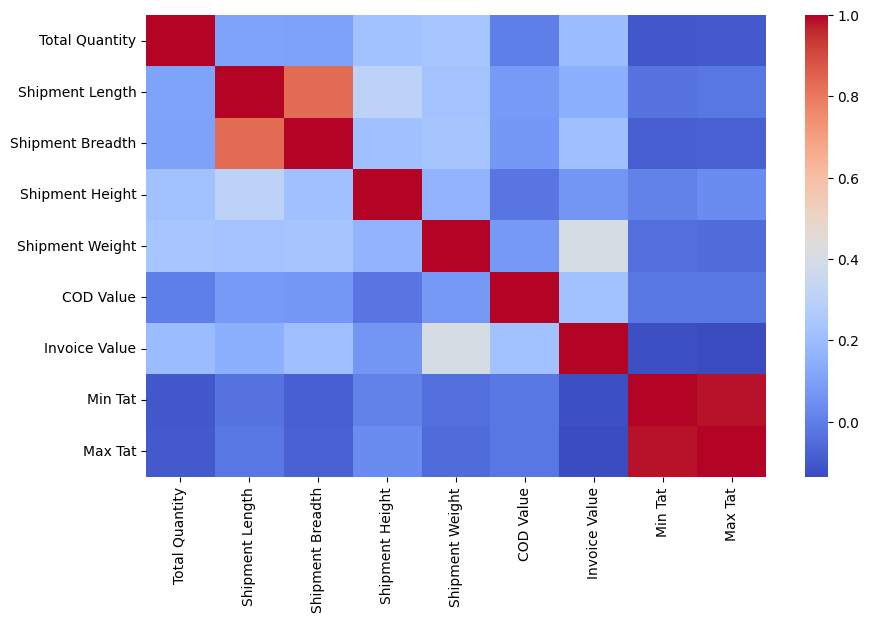

In [113]:

plt.figure(figsize=(10,6))
sns.heatmap(df_delivered[num_cols].select_dtypes(include='number').corr(),cmap='coolwarm')
plt.show()

In [23]:
corr_matrix = df_delivered.select_dtypes(include='number').corr()
corr_matrix


,Pickup Pincode,Drop Pincode,Total Quantity,Shipment Length,Shipment Breadth,Shipment Height,Shipment Weight,COD Value,Invoice Value,Min Tat,Max Tat,delivery_delay
Pickup Pincode,1.000000,0.326551,0.075148,0.004067,0.071929,-0.034219,0.096456,-0.024508,0.078176,-0.135697,-0.133923,-0.039724
Drop Pincode,0.326551,1.000000,0.009907,0.006210,0.010951,-0.006474,0.043312,-0.038069,-0.024612,0.202191,0.184336,-0.010416
Total Quantity,0.075148,0.009907,1.000000,0.104022,0.101125,0.215132,0.235643,-0.000291,0.194001,-0.108136,-0.098569,0.049693
Shipment Length,0.004067,0.006210,0.104022,1.000000,0.830070,0.304779,0.221489,0.078534,0.150623,-0.032216,-0.021529,0.050258
Shipment Breadth,0.071929,0.010951,0.101125,0.830070,1.000000,0.212190,0.227891,0.068766,0.205519,-0.086278,-0.083103,0.056887
Shipment Height,-0.034219,-0.006474,0.215132,0.304779,0.212190,1.000000,0.163709,-0.027665,0.066657,0.007217,0.034752,0.035060
Shipment Weight,0.096456,0.043312,0.235643,0.221489,0.227891,0.163709,1.000000,0.076214,0.404603,-0.045086,-0.054511,0.079228
COD Value,-0.024508,-0.038069,-0.000291,0.078534,0.068766,-0.027665,0.076214,1.000000,0.217701,-0.018741,-0.022966,0.016366
Invoice Value,0.078176,-0.024612,0.194001,0.150623,0.205519,0.066657,0.404603,0.217701,1.000000,-0.125864,-0.136371,0.080135
Min Tat,-0.135697,0.202191,-0.108136,-0.032216,-0.086278,0.007217,-0.045086,-0.018741,-0.125864,1.000000,0.985906,-0.424751


In [24]:
pd.crosstab(
    df_delivered['Courier Partner'],
    df_delivered['delivery_delay'],
    normalize='index'
).sort_values(1, ascending=False).head(10)


delivery_delay,0,1
Courier Partner,,
BLITZ SDD,0.000000,1.000000
SHADOWFAX_NDD_HEAVY,0.000000,1.000000
XPRESSBEES SDD,0.000000,1.000000
PIKNDEL,0.000000,1.000000
SHIPLOG FORWARD,0.000395,0.999605
DTDC SURFACE,0.019868,0.980132
BLITZ,0.210454,0.789546
XPRESSBEES AIR,0.265487,0.734513
BLUEDART AIR,0.306580,0.693420


In [25]:
pd.crosstab(
    df_delivered['Zone'],
    df_delivered['delivery_delay'],
    normalize='index'
)


delivery_delay,0,1
Zone,,
LOCAL,0.229053,0.770947
METROS,0.312937,0.687063
REGIONAL,0.545423,0.454577
ROI,0.608280,0.391720
SPECIAL,0.730597,0.269403


In [26]:
pd.crosstab(
    df_delivered['Payment Mode'],
    df_delivered['delivery_delay'],
    normalize='index'
)


delivery_delay,0,1
Payment Mode,,
COD,0.543708,0.456292
PREPAID,0.513708,0.486292


In [27]:
df_delivered['shipment_volume'] = (
    df_delivered['Shipment Length'] *
    df_delivered['Shipment Breadth'] *
    df_delivered['Shipment Height'])


In [28]:
df_delivered['order_day'] = df_delivered['Order Date'].dt.day_name()
df_delivered['order_month'] = df_delivered['Order Date'].dt.month


In [29]:
df_delivered['volume_bucket'] = pd.qcut(
    df_delivered['shipment_volume'],
    q=5,
    duplicates='drop'
)

#Delay rate increasing with volume buckets = strong predictive signal
volume_delay = df_delivered.groupby('volume_bucket')['delivery_delay'].mean()
volume_delay
#“As shipment volume increases, operational handling complexity rises, increasing the likelihood of delivery delays.”

C:\Users\bharg\AppData\Local\Temp\ipykernel_4420\1325752030.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_delay = df_delivered.groupby('volume_bucket')['delivery_delay'].mean()


volume_bucket
(0.0, 100.0]          0.376674
(100.0, 225.0]        0.532452
(225.0, 1000.0]       0.567147
(1000.0, 3680.0]      0.448951
(3680.0, 357000.0]    0.520550
Name: delivery_delay, dtype: float64

In [30]:
day_delay = df_delivered.groupby('order_day')['delivery_delay'].mean()
day_delay
#Orders created on certain weekdays show higher delay probability, indicating operational congestion and staffing effects
#“Temporal order-creation effects exhibit moderate variation, suggesting weekday congestion and staffing patterns.”

order_day
Friday       0.465855
Monday       0.469150
Saturday     0.484466
Sunday       0.462581
Thursday     0.482278
Tuesday      0.470850
Wednesday    0.501369
Name: delivery_delay, dtype: float64

In [31]:
month_delay = df_delivered.groupby('order_month')['delivery_delay'].mean()
month_delay
#order month vs delay 
#“Temporal order-creation effects exhibit moderate variation, suggesting weekday congestion and staffing patterns.”

order_month
10    0.477971
Name: delivery_delay, dtype: float64

In [32]:
courier_delay = (
    df_delivered
    .groupby('Courier Partner')['delivery_delay']
    .mean()
    .sort_values(ascending=False)
)

courier_delay.head(10)
#“Significant heterogeneity in courier delay performance suggests strong potential for data-driven courier allocation.”


Courier Partner
BLITZ SDD              1.000000
SHADOWFAX_NDD_HEAVY    1.000000
XPRESSBEES SDD         1.000000
PIKNDEL                1.000000
SHIPLOG FORWARD        0.999605
DTDC SURFACE           0.980132
BLITZ                  0.789546
XPRESSBEES AIR         0.734513
BLUEDART AIR           0.693420
DELHIVERY AIR          0.666907
Name: delivery_delay, dtype: float64

In [33]:
#Promised delivery delays
# Create promised delivery days
df_delivered['promised_days'] = (
    df_delivered['promised_last_date'] - df_delivered['Order Date']
).dt.days

# Check distribution
df_delivered['promised_days'].describe()
#“Most orders are promised delivery within 3–6 days, indicating tight service-level commitments where even small operational disruptions can lead to delays.”


count    213808.000000
mean          4.631674
std           2.059514
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max           9.000000
Name: promised_days, dtype: float64

In [34]:
df_delivered['promised_days_bucket'] = pd.cut(
    df_delivered['promised_days'],
    bins=[0, 2, 4, 7, 14, 30],
    labels=['1-2', '3-4', '5-7', '8-14', '15+']
)

# Delay rate by bucket
promised_delay = (
    df_delivered
    .groupby('promised_days_bucket')['delivery_delay']
    .mean()
)

promised_delay
#“Delivery delay probability decreases sharply as promised delivery windows increase, with orders promised within 1–2 days exhibiting nearly 80% delay rates. This highlights SLA tightness as the strongest driver of delivery risk.”


C:\Users\bharg\AppData\Local\Temp\ipykernel_4420\1084114156.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('promised_days_bucket')['delivery_delay']


promised_days_bucket
1-2     0.790819
3-4     0.602549
5-7     0.329518
8-14    0.175394
15+          NaN
Name: delivery_delay, dtype: float64

In [36]:
# Create weekend flag
df_delivered['is_weekend'] = df_delivered['order_day'].isin(
    ['Saturday', 'Sunday']
).astype(int)

# Compare delay rates
weekend_delay = (
    df_delivered
    .groupby('is_weekend')['delivery_delay']
    .mean()
)

weekend_delay
#Weekend order creation exhibits negligible difference in delay rates, suggesting that weekend effects are secondary compared to SLA and courier performance.”


is_weekend
0    0.478654
1    0.475745
Name: delivery_delay, dtype: float64

In [37]:
# Calculate historical delay rate per courier
courier_delay_rate = (
    df_delivered
    .groupby('Courier Partner')['delivery_delay']
    .mean()
)

# Map back to dataframe
df_delivered['courier_delay_rate'] = (
    df_delivered['Courier Partner']
    .map(courier_delay_rate)
)

# Validate
df_delivered[['Courier Partner', 'courier_delay_rate']].drop_duplicates().head()
#“Courier partners exhibit substantial heterogeneity in delivery performance, with some partners showing near-certain delays. Historical courier delay rate is therefore a critical predictor of future delivery reliability.”


,Courier Partner,courier_delay_rate
1,DELHIVERY SURFACE,0.412135
10,EKART,0.372107
13,SHIPLOG FORWARD,0.999605
15,EKART SURFACE,0.646719
23,PIKNDEL,1.000000


In [38]:
num_features = [
    'Shipment Weight',
    'shipment_volume',
    'promised_days',
    'courier_delay_rate'
]

cat_features = [
    'Courier Partner',
    'order_day',
    'promised_days_bucket'
]

bin_features = ['is_weekend']

features = num_features + cat_features + bin_features

X = df_delivered[features]
y = df_delivered['delivery_delay']


In [40]:
#“Final features were selected based on data availability and business relevance, focusing on shipment characteristics, SLA tightness, temporal order attributes, and courier historical performance.”

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


“The dataset was split into training and test subsets using stratified sampling to preserve the proportion of delayed deliveries.”

Logistic Regression

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
log_reg_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

log_reg_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [133]:
from sklearn.metrics import classification_report, roc_auc_score
y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.70      0.78      0.74     33485
           1       0.73      0.63      0.68     30658

    accuracy                           0.71     64143
   macro avg       0.71      0.71      0.71     64143
weighted avg       0.71      0.71      0.71     64143

ROC-AUC: 0.775028562470143


In [134]:
import pandas as pd

# Get feature names after encoding
feature_names = (
    log_reg_model
    .named_steps['preprocess']
    .get_feature_names_out()
)

coefficients = log_reg_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

coef_df.head(10), coef_df.tail(10)


(                                       feature  coefficient
 20        cat__Courier Partner_SHIPLOG FORWARD     1.542601
 4             cat__Courier Partner_ATS SURFACE     1.122893
 35              cat__promised_days_bucket_8-14     0.998515
 3                      num__courier_delay_rate     0.938726
 15                cat__Courier Partner_PIKNDEL     0.590774
 8        cat__Courier Partner_BLUEDART SURFACE     0.539320
 18  cat__Courier Partner_SHADOWFAX MATKETPLACE     0.363539
 10      cat__Courier Partner_DELHIVERY SURFACE     0.230587
 36               cat__promised_days_bucket_nan     0.211156
 13                  cat__Courier Partner_EKART     0.210492,
                                     feature  coefficient
 28                    cat__order_day_Sunday    -0.159389
 24  cat__Courier Partner_XPRESSBEES SURFACE    -0.166405
 9        cat__Courier Partner_DELHIVERY AIR    -0.260854
 21      cat__Courier Partner_XPRESSBEES 5KG    -0.316825
 32            cat__promised_days_buck

Random forest

In [135]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)


In [136]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

           0       0.75      0.78      0.76     33485
           1       0.75      0.71      0.73     30658

    accuracy                           0.75     64143
   macro avg       0.75      0.75      0.75     64143
weighted avg       0.75      0.75      0.75     64143

ROC-AUC: 0.8276105350572047


The Random Forest model significantly outperformed the logistic regression baseline, achieving a recall of 71% for delayed deliveries and an ROC-AUC of 0.83, indicating superior non-linear pattern capture.”

Enhanced model

In [139]:
# -------------------------
# BASE FEATURE SET
# -------------------------

num_features_base = [
    'Shipment Weight',
    'shipment_volume',
    'promised_days',
    'courier_delay_rate'
]

cat_features_base = [
    'Courier Partner',
    'order_day',
    'promised_days_bucket'
]

bin_features_base = ['is_weekend']

features_base = num_features_base + cat_features_base + bin_features_base


In [140]:
X_base = df_delivered[features_base]
y = df_delivered['delivery_delay']

from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


In [141]:
for col in cat_features_base:
    Xb_train[col] = Xb_train[col].astype(str).fillna('missing')
    Xb_test[col] = Xb_test[col].astype(str).fillna('missing')


In [142]:
cat_idx_base = [Xb_train.columns.get_loc(col) for col in cat_features_base]


In [144]:
from catboost import CatBoostClassifier

cat_base = CatBoostClassifier(
    iterations=400,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cat_base.fit(
    Xb_train,
    yb_train,
    cat_features=cat_idx_base,
    eval_set=(Xb_test, yb_test)
)


0:	test: 0.7834834	best: 0.7834834 (0)	total: 147ms	remaining: 58.6s
100:	test: 0.8218241	best: 0.8218241 (100)	total: 22.5s	remaining: 1m 6s
200:	test: 0.8281387	best: 0.8281387 (200)	total: 47.1s	remaining: 46.7s
300:	test: 0.8321153	best: 0.8321153 (300)	total: 1m 37s	remaining: 32.1s
399:	test: 0.8344359	best: 0.8344417 (398)	total: 2m 49s	remaining: 0us

bestTest = 0.8344416521
bestIteration = 398

Shrink model to first 399 iterations.


In [145]:
from sklearn.metrics import classification_report, roc_auc_score

yb_pred = cat_base.predict(Xb_test)
yb_prob = cat_base.predict_proba(Xb_test)[:, 1]

print(classification_report(yb_test, yb_pred))
print("Base CatBoost ROC-AUC:", roc_auc_score(yb_test, yb_prob))


              precision    recall  f1-score   support

           0       0.76      0.78      0.77     33485
           1       0.75      0.73      0.74     30658

    accuracy                           0.76     64143
   macro avg       0.76      0.75      0.76     64143
weighted avg       0.76      0.76      0.76     64143

Base CatBoost ROC-AUC: 0.8344416520852043


Synthetic

In [149]:
df_delivered['delay_days'] = (
    df_delivered['Delivery Date'] - df_delivered['promised_last_date']
).dt.days

df_delivered['delay_days'] = df_delivered['delay_days'].clip(lower=0)


In [150]:
num_features_syn = num_features + ['delay_days']

cat_features_syn = cat_features
bin_features_syn = bin_features

features_syn = num_features_syn + cat_features_syn + bin_features_syn

In [151]:
X_syn = df_delivered[features_syn]
y = df_delivered['delivery_delay']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_syn,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


In [152]:
for col in cat_features_syn:
    Xs_train[col] = Xs_train[col].astype(str).fillna('missing')
    Xs_test[col] = Xs_test[col].astype(str).fillna('missing')

cat_idx_syn = [Xs_train.columns.get_loc(col) for col in cat_features_syn]


In [153]:
cat_syn = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cat_syn.fit(
    Xs_train,
    ys_train,
    cat_features=cat_idx_syn,
    eval_set=(Xs_test, ys_test)
)


0:	test: 0.8955369	best: 0.8955369 (0)	total: 153ms	remaining: 1m 16s
100:	test: 0.9198411	best: 0.9198411 (100)	total: 49.7s	remaining: 3m 16s
200:	test: 0.9218807	best: 0.9218807 (200)	total: 1m 10s	remaining: 1m 44s
300:	test: 0.9230211	best: 0.9230211 (300)	total: 1m 44s	remaining: 1m 9s
400:	test: 0.9240313	best: 0.9240353 (399)	total: 3m 14s	remaining: 47.9s
499:	test: 0.9246534	best: 0.9246534 (499)	total: 4m 17s	remaining: 0us

bestTest = 0.9246534175
bestIteration = 499



In [154]:
ys_pred = cat_syn.predict(Xs_test)
ys_prob = cat_syn.predict_proba(Xs_test)[:, 1]

print(classification_report(ys_test, ys_pred))
print("Synthetic CatBoost ROC-AUC:", roc_auc_score(ys_test, ys_prob))


              precision    recall  f1-score   support

           0       0.81      0.92      0.87     33485
           1       0.90      0.77      0.83     30658

    accuracy                           0.85     64143
   macro avg       0.86      0.85      0.85     64143
weighted avg       0.86      0.85      0.85     64143

Synthetic CatBoost ROC-AUC: 0.924653417497714
